In [1]:
import gds_geometry_evaluator as gds

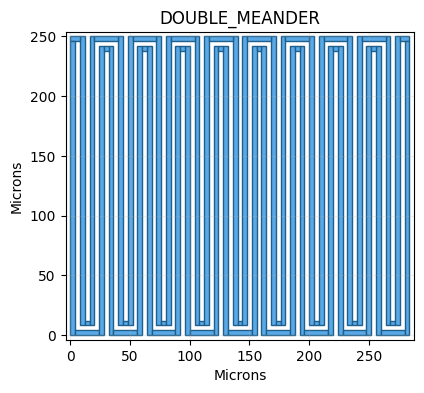

Output GDS: not saved
Cell: DOUBLE_MEANDER
Trace width (microns): 4
Gap width (microns): 4
Inner meander gap width (microns): 4
Leg count per lobe: 10
Total length (microns): 9144
Number of squares: 2286
Outer cell height (microns): 242
Return cell height (microns): 242
Return bridge length (microns): 4
Bounding box (microns): 284 x 250

Evaluated geometry:
GDS file: /tmp/tmpzqce8mes/DOUBLE_MEANDER.gds
Cells: DOUBLE_MEANDER
Layer filter: layer 1, datatype 0
Library unit (microns): 1
Area (square microns): 36576
Trace width (microns): 4
Effective length (microns): 9144
Number of squares: 2286
Film thickness (nanometers): 30
Total volume (cubic microns): 1097.28


In [2]:
inductor_spec = gds.DoubleMeanderSpec(
    trace_width_microns=4.0,
    gap_width_microns=4.0,
    bounding_box_width_microns=284.0,
    bounding_box_height_microns=250.0,
    meander_inner_gap_width_microns=4.0,
    # target_number_of_squares=11000.0,
    layer=1,
)
inductor_built = gds.build_double_meander(inductor_spec)
inductor_built.plot()

inductor_eval = gds.evaluate_generated_double_meander(inductor_spec, save_path=None, film_thickness_nanometers=30.0)
print(inductor_eval)

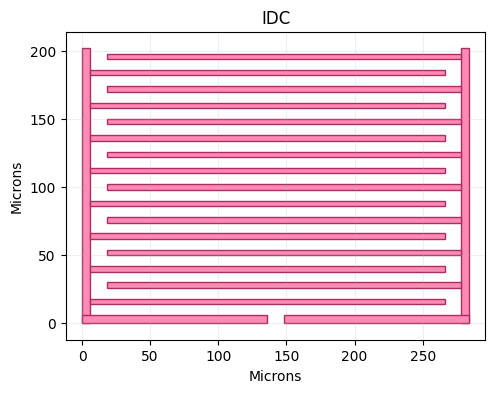

Output GDS: not saved
Cell: IDC
Finger count: 16
Left finger count: 8
Right finger count: 8
Finger trace width (microns): 4
Finger length (microns): 260
Final finger length fraction: 1.0
Finger gap width (microns): 8
Finger tip gap width (microns): 8
Arm trace width (microns): 6
Arm gap width (microns): 12
Top arm stubs omitted: False
Bounding box (microns): 284 x 202

Evaluated IDC geometry:
GDS file: /tmp/tmp0d3b84x8/IDC.gds
Cells: IDC
Layer filter: layer 2, datatype 0
Inferred capacitor model: idc
Inferred finger orientation: horizontal
Inferred finger count: 17
Adjacent finger pairs: 16
Inferred finger width (microns): 4
Inferred gap (microns): 8
Inferred pitch (microns): 12
Inferred finger length (microns): 260
Inferred active overlap length (microns): 248
Inferred active span (microns): 198
Inferred bounding box (microns): 278 x 198

Estimated IDC capacitance:
GDS file: /tmp/tmp0d3b84x8/IDC.gds
Cells: IDC
Layer filter: layer 2, datatype 0
Inferred capacitor model: idc
Effective p

In [3]:
idc_spec = gds.IdcSpec(
    finger_count=16,
    finger_trace_width_microns=4.0,
    finger_length_microns=260.0,
    finger_gap_width_microns=8.0,
    arm_trace_width_microns=6.0,
    arm_gap_width_microns=12.0,
    bounding_box_width_microns=284.0,
    final_finger_length_fraction=1.0,
    include_bottom_bars=True,
    omit_top_arm_stubs=False,
    layer=2,
)
idc_built = gds.build_idc(idc_spec)
idc_built.plot()

idc_eval = gds.evaluate_generated_idc(idc_spec, save_path=None, effective_permittivity=9.08)
print(idc_eval)

In [4]:
ground_shield_spec = gds.GroundShieldSpec(
    trace_thickness_microns=20,
    horizontal_gap_microns=20,
    upper_gap_microns=20,
    lower_gap_microns=20,
)

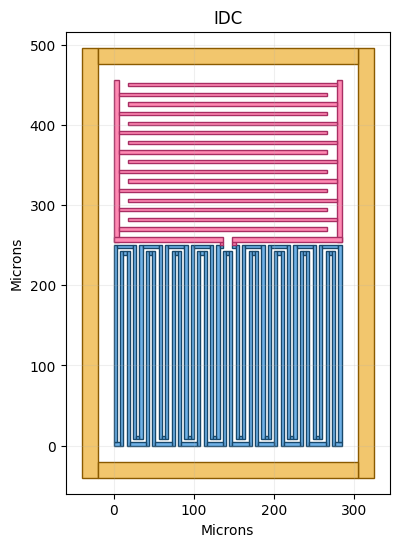

Output GDS: not saved
Cell: IDC
Inductor layer/datatype: 1/0
Capacitor layer/datatype: 2/0
Inductor trace width (microns): 4
Inductor gap width (microns): 4
Inductor leg count per lobe: 10
Inductor bounding box (microns): 284 x 250
IDC finger count: 16
IDC finger trace width (microns): 4
IDC finger length (microns): 260
IDC finger gap width (microns): 8
IDC arm trace width (microns): 6
IDC arm gap width (microns): 12
IDC bottom bars included: True
IDC top arm stubs omitted: False
Bridge gap width (microns): 12
Assembly bounding box (microns): 364 x 536
Ground shield layer/datatype: 3/0
Ground shield trace thickness (microns): 20
Ground shield horizontal gap (microns): 20
Ground shield upper gap (microns): 20
Ground shield lower gap (microns): 20

Estimated resonator properties:
Geometric inductance estimation method: meander-aware-double
Requested meander mode: double
Film thickness (nanometers): 30
Inductor volume (cubic microns): 1095.84
Inductive area (square microns): 36528
Inducti

In [5]:
built_lekid = gds.build_double_meander_with_idc(
                        inductor_spec=inductor_spec,
                        idc_spec=idc_spec,
                        ground_shield_spec=ground_shield_spec,
                        )

built_lekid.plot()

lekid_eval = gds.evaluate_generated_double_meander_with_idc(built_lekid, 
                                               effective_permittivity=9.08, 
                                               kinetic_inductance_per_square_nh=0.0, 
                                               film_thickness_nanometers=30.0
                                              )

print(lekid_eval)

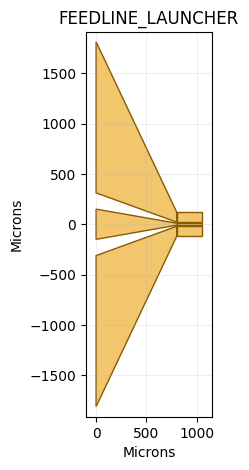

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'FEEDLINE_LAUNCHER'}, xlabel='Microns', ylabel='Microns'>)

In [6]:
fl_launch_spec = gds.FeedlineLauncherSpec(
    central_conductor_width_microns=20,
    gap_width_microns=10.75,
    ground_conductor_width_microns=100,
    signal_bond_pad_edge_width_microns=300,
    ground_bond_pad_edge_width_microns=1500,
    template_path="/home/dtemples/GDS-Geometry-Evaluator/assets/feedlines/feedline-launch-caltech-style.gds",
    layer=3,
    datatype=0,
)

fl_launch_built = gds.build_feedline_launcher(fl_launch_spec)
fl_launch_built.plot()

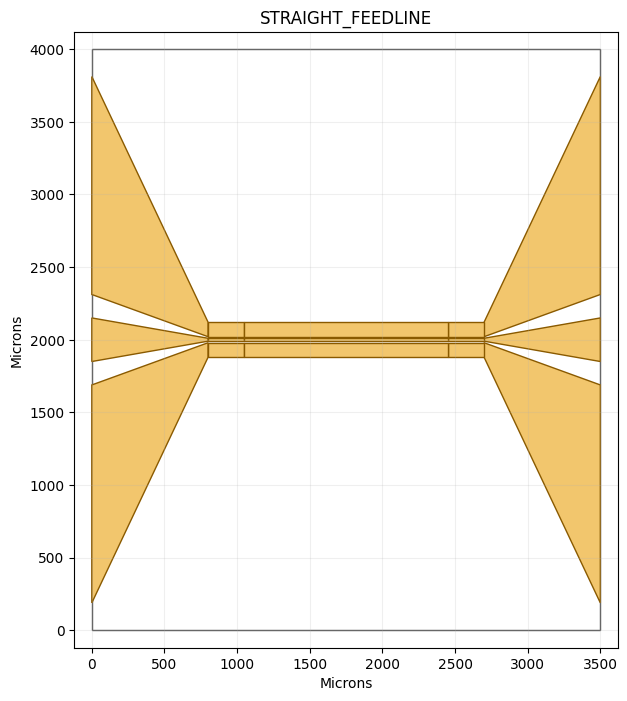

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'STRAIGHT_FEEDLINE'}, xlabel='Microns', ylabel='Microns'>)

In [7]:
fl_spec = gds.StraightFeedlineSpec(
    launcher_spec=fl_launch_spec,
    chip_width_microns=3500,
    chip_height_microns=4000,
    face="left",
    offset_microns=0,
)

built_fl = gds.build_straight_feedline(fl_spec)
built_fl.plot()

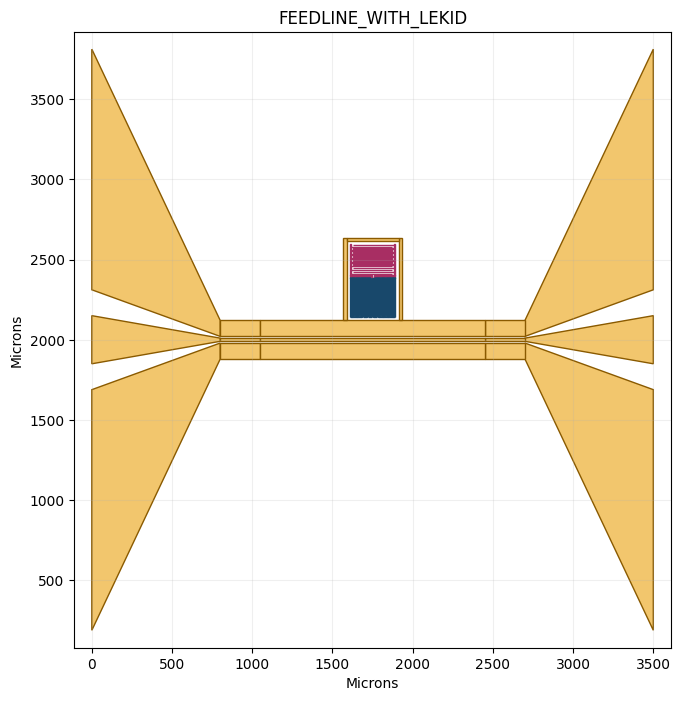

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'FEEDLINE_WITH_LEKID'}, xlabel='Microns', ylabel='Microns'>)

In [8]:
placed = gds.place_lekid_on_feedline(
    feedline_result=built_fl,
    lekid_result=built_lekid,
    spec=gds.LekidFeedlinePlacementSpec(
        separation_microns=20.0,
        position_microns=0.0,
        row_index=0,
    ),
)

placed.plot()

In [9]:
gds.write_built_gds("./LowVolResonator1.gds", placed)

LekidFeedlinePlacementResult(spec=LekidFeedlinePlacementSpec(separation_microns=20.0, position_microns=0.0, row_index=0, cell_name='FEEDLINE_WITH_LEKID', erase_feedline_from_ground_shield=True), feedline_result=StraightFeedlineResult(spec=StraightFeedlineSpec(launcher_spec=FeedlineLauncherSpec(central_conductor_width_microns=20, gap_width_microns=10.75, ground_conductor_width_microns=100, signal_bond_pad_edge_width_microns=300, ground_bond_pad_edge_width_microns=1500, template_path='/home/dtemples/GDS-Geometry-Evaluator/assets/feedlines/feedline-launch-caltech-style.gds', layer=3, datatype=0, cell_name='FEEDLINE_LAUNCHER', origin_x_microns=0.0, origin_y_microns=0.0, include_ground_bond_pads=False, bond_pad_gap_width_microns=None, edge_rounding_radius_microns=20.0), chip_width_microns=3500, chip_height_microns=4000, face='left', offset_microns=0, cell_name='STRAIGHT_FEEDLINE'), launcher_result=FeedlineLauncherResult(spec=FeedlineLauncherSpec(central_conductor_width_microns=20, gap_width